In [3]:
import pandas as pd

df = pd.read_excel("marketing_campaign_dataset.xlsx")

df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Date,Clicks,Impressions,Engagement_Score,Customer_Segment
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,16174,6.29,Chicago,2021-01-01 00:00:00,506,1922,6,Health & Wellness
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,11566,5.61,New York,2021-02-01 00:00:00,116,7523,7,Fashionistas
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,10200,7.18,Los Angeles,2021-03-01 00:00:00,584,7698,1,Outdoor Adventurers
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,12724,5.55,Miami,2021-04-01 00:00:00,217,1820,7,Health & Wellness
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,16452,6.50,Los Angeles,2021-05-01 00:00:00,379,4201,3,Health & Wellness


In [4]:
df.shape

(200005, 15)

In [5]:
df.columns

Index(['Campaign_ID', 'Company', 'Campaign_Type', 'Target_Audience',
       'Duration', 'Channel_Used', 'Conversion_Rate', 'Acquisition_Cost',
       'ROI', 'Location', 'Date', 'Clicks', 'Impressions', 'Engagement_Score',
       'Customer_Segment'],
      dtype='str')

In [6]:
df.isnull().sum()

Campaign_ID         0
Company             0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Conversion_Rate     0
Acquisition_Cost    0
ROI                 0
Location            0
Date                0
Clicks              0
Impressions         0
Engagement_Score    0
Customer_Segment    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200005 entries, 0 to 200004
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200005 non-null  int64  
 1   Company           200005 non-null  str    
 2   Campaign_Type     200005 non-null  str    
 3   Target_Audience   200005 non-null  str    
 4   Duration          200005 non-null  str    
 5   Channel_Used      200005 non-null  str    
 6   Conversion_Rate   200005 non-null  float64
 7   Acquisition_Cost  200005 non-null  int64  
 8   ROI               200005 non-null  float64
 9   Location          200005 non-null  str    
 10  Date              200005 non-null  object 
 11  Clicks            200005 non-null  int64  
 12  Impressions       200005 non-null  int64  
 13  Engagement_Score  200005 non-null  int64  
 14  Customer_Segment  200005 non-null  str    
dtypes: float64(2), int64(5), object(1), str(7)
memory usage: 22.9+ MB


In [9]:
df['Date'] = pd.to_datetime(df['Date'])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200005 entries, 0 to 200004
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Campaign_ID       200005 non-null  int64         
 1   Company           200005 non-null  str           
 2   Campaign_Type     200005 non-null  str           
 3   Target_Audience   200005 non-null  str           
 4   Duration          200005 non-null  str           
 5   Channel_Used      200005 non-null  str           
 6   Conversion_Rate   200005 non-null  float64       
 7   Acquisition_Cost  200005 non-null  int64         
 8   ROI               200005 non-null  float64       
 9   Location          200005 non-null  str           
 10  Date              200005 non-null  datetime64[us]
 11  Clicks            200005 non-null  int64         
 12  Impressions       200005 non-null  int64         
 13  Engagement_Score  200005 non-null  int64         
 14  Customer_Segmen

In [10]:
df[['Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Clicks',
    'Impressions', 'Engagement_Score']].describe()

,Conversion_Rate,Acquisition_Cost,ROI,Clicks,Impressions,Engagement_Score
count,200005.000000,200005.000000,200005.000000,200005.000000,200005.000000,200005.000000
mean,0.080069,12504.441794,5.002416,549.774591,5507.307107,5.494673
std,0.040602,4337.663210,1.734485,260.019354,2596.863794,2.872593
min,0.010000,5000.000000,2.000000,100.000000,1000.000000,1.000000
25%,0.050000,8740.000000,3.500000,325.000000,3266.000000,3.000000
50%,0.080000,12497.000000,5.010000,550.000000,5518.000000,5.000000
75%,0.120000,16264.000000,6.510000,775.000000,7753.000000,8.000000
max,0.150000,20000.000000,8.000000,1000.000000,10000.000000,10.000000


In [11]:
df['Channel_Used'].value_counts()

Channel_Used
Email         33599
Google Ads    33440
YouTube       33393
Instagram     33392
Website       33361
Facebook      32820
Name: count, dtype: int64

In [12]:
channel_roi = df.groupby('Channel_Used')['ROI'].mean().sort_values(ascending=False)

channel_roi

Channel_Used
Facebook      5.018672
Website       5.014114
Google Ads    5.003126
Email         4.996487
YouTube       4.993720
Instagram     4.988706
Name: ROI, dtype: float64

In [13]:
channel_performance = df.groupby('Channel_Used').agg({
    'ROI': 'mean',
    'Conversion_Rate': 'mean',
    'Acquisition_Cost': 'mean',
    'Clicks': 'mean',
    'Impressions': 'mean',
    'Engagement_Score': 'mean'
}).sort_values('ROI', ascending=False)

channel_performance

,ROI,Conversion_Rate,Acquisition_Cost,Clicks,Impressions,Engagement_Score
Channel_Used,,,,,,
Facebook,5.018672,0.079990,12510.768617,549.609232,5504.646435,5.503748
Website,5.014114,0.080182,12487.842001,552.002368,5509.903810,5.508828
Google Ads,5.003126,0.080181,12528.245036,548.522398,5532.899342,5.493989
Email,4.996487,0.080282,12526.387809,550.431947,5500.196643,5.487842
YouTube,4.993720,0.079890,12481.570688,549.544366,5493.691642,5.484802
Instagram,4.988706,0.079886,12491.760002,548.534200,5502.469304,5.489039


In [14]:
funnel = {
    'Impressions': df['Impressions'].sum(),
    'Clicks': df['Clicks'].sum(),
    'Conversions': (df['Clicks'] * df['Conversion_Rate']).sum()
}

funnel

{'Impressions': np.int64(1101488958),
 'Clicks': np.int64(109957667),
 'Conversions': np.float64(8804733.92)}

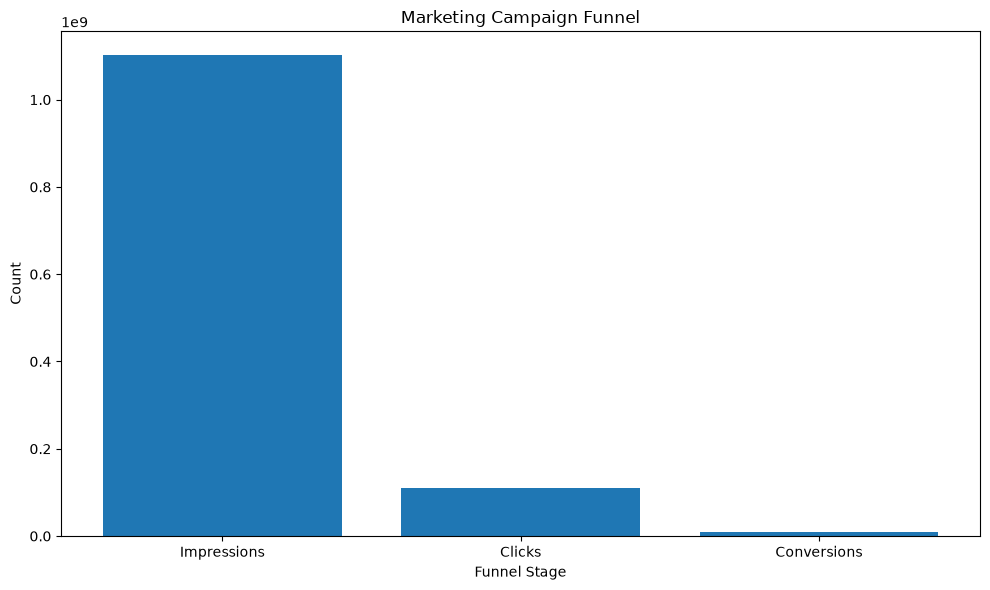

In [15]:
import matplotlib.pyplot as plt

funnel_labels = ['Impressions', 'Clicks', 'Conversions']
funnel_values = [
    funnel['Impressions'],
    funnel['Clicks'],
    funnel['Conversions']
]

plt.figure(figsize=(10, 6))
plt.bar(funnel_labels, funnel_values)
plt.title('Marketing Campaign Funnel')
plt.xlabel('Funnel Stage')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [16]:
impressions = df['Impressions'].sum()
clicks = df['Clicks'].sum()
conversions = (df['Clicks'] * df['Conversion_Rate']).sum()

click_through_rate = (clicks / impressions) * 100
conversion_rate = (conversions / clicks) * 100

print(f"Click-Through Rate: {click_through_rate:.2f}%")
print(f"Click-to-Conversion Rate: {conversion_rate:.2f}%")

Click-Through Rate: 9.98%
Click-to-Conversion Rate: 8.01%


In [17]:
channel_conversion = (
    df.groupby('Channel_Used')['Conversion_Rate']
      .mean()
      .sort_values(ascending=False)
)

channel_conversion

Channel_Used
Email         0.080282
Website       0.080182
Google Ads    0.080181
Facebook      0.079990
YouTube       0.079890
Instagram     0.079886
Name: Conversion_Rate, dtype: float64

In [18]:
channel_business = df.groupby('Channel_Used').agg(
    Avg_ROI=('ROI', 'mean'),
    Avg_Acquisition_Cost=('Acquisition_Cost', 'mean'),
    Avg_Conversion_Rate=('Conversion_Rate', 'mean'),
    Total_Clicks=('Clicks', 'sum'),
    Total_Impressions=('Impressions', 'sum')
).sort_values('Avg_ROI', ascending=False)

channel_business

,Avg_ROI,Avg_Acquisition_Cost,Avg_Conversion_Rate,Total_Clicks,Total_Impressions
Channel_Used,,,,,
Facebook,5.018672,12510.768617,0.079990,18038175,180662496
Website,5.014114,12487.842001,0.080182,18415351,183815901
Google Ads,5.003126,12528.245036,0.080181,18342589,185020154
Email,4.996487,12526.387809,0.080282,18493963,184801107
YouTube,4.993720,12481.570688,0.079890,18350935,183450845
Instagram,4.988706,12491.760002,0.079886,18316654,183738455


In [19]:
campaign_performance = df.groupby('Campaign_Type').agg(
    Avg_ROI=('ROI', 'mean'),
    Avg_Conversion_Rate=('Conversion_Rate', 'mean'),
    Avg_Acquisition_Cost=('Acquisition_Cost', 'mean'),
    Avg_Engagement=('Engagement_Score', 'mean')
).sort_values('Avg_ROI', ascending=False)

campaign_performance

,Avg_ROI,Avg_Conversion_Rate,Avg_Acquisition_Cost,Avg_Engagement
Campaign_Type,,,,
Influencer,5.011040,0.080315,12507.319716,5.483022
Search,5.008357,0.080021,12498.736459,5.487138
Display,5.006497,0.080088,12508.180929,5.505777
Email,4.994274,0.079787,12495.237566,5.499661
Social Media,4.991781,0.080132,12512.753510,5.497878


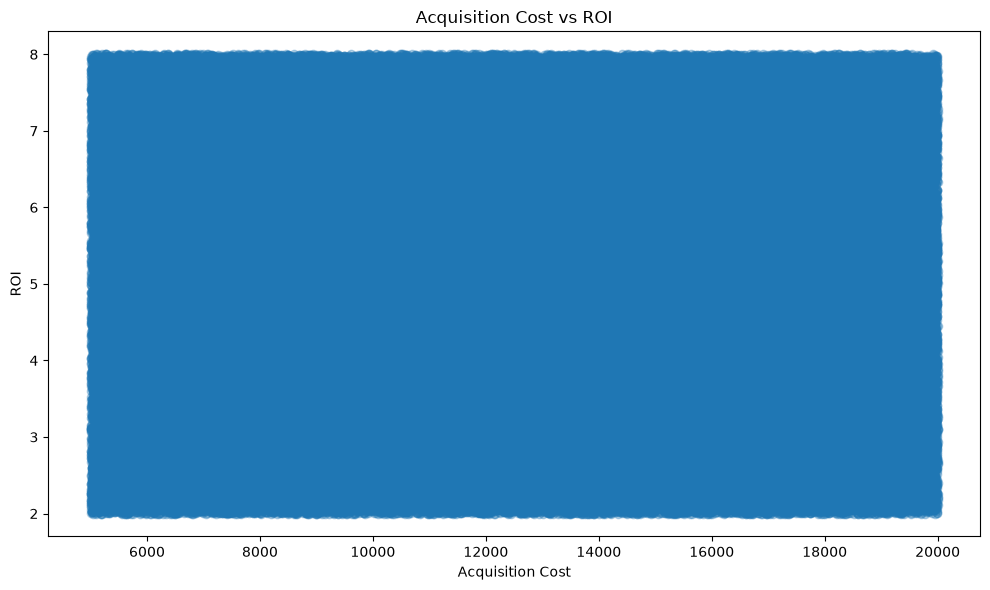

In [20]:
plt.figure(figsize=(10, 6))

plt.scatter(df['Acquisition_Cost'], df['ROI'], alpha=0.3)

plt.title('Acquisition Cost vs ROI')
plt.xlabel('Acquisition Cost')
plt.ylabel('ROI')

plt.tight_layout()
plt.show()

In [21]:
correlation = df['Acquisition_Cost'].corr(df['ROI'])

print(f"Correlation between Acquisition Cost and ROI: {correlation:.4f}")

Correlation between Acquisition Cost and ROI: 0.0046


In [22]:
channel_scorecard = df.groupby('Channel_Used').agg(
    Avg_ROI=('ROI', 'mean'),
    Avg_Conversion_Rate=('Conversion_Rate', 'mean'),
    Avg_Engagement=('Engagement_Score', 'mean')
)

channel_scorecard

,Avg_ROI,Avg_Conversion_Rate,Avg_Engagement
Channel_Used,,,
Email,4.996487,0.080282,5.487842
Facebook,5.018672,0.079990,5.503748
Google Ads,5.003126,0.080181,5.493989
Instagram,4.988706,0.079886,5.489039
Website,5.014114,0.080182,5.508828
YouTube,4.993720,0.079890,5.484802


<Axes: title={'center': 'Average ROI by Channel'}, xlabel='Channel', ylabel='Average ROI'>

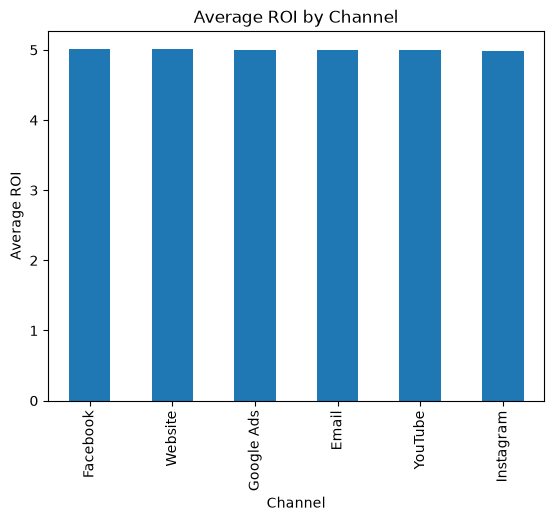

In [23]:
channel_scorecard['Avg_ROI'].sort_values(ascending=False).plot(
    kind='bar',
    title='Average ROI by Channel',
    ylabel='Average ROI',
    xlabel='Channel'
)

<Axes: title={'center': 'Average ROI by Channel'}, xlabel='Channel', ylabel='Average ROI'>

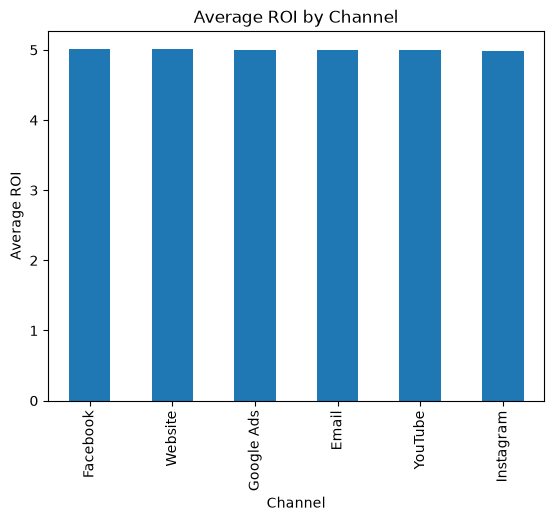

In [24]:
channel_scorecard['Avg_ROI'].sort_values(ascending=False).plot(
    kind='bar',
    title='Average ROI by Channel',
    ylabel='Average ROI',
    xlabel='Channel'
)

<Axes: title={'center': 'Average Conversion Rate by Channel'}, xlabel='Channel', ylabel='Average Conversion Rate'>

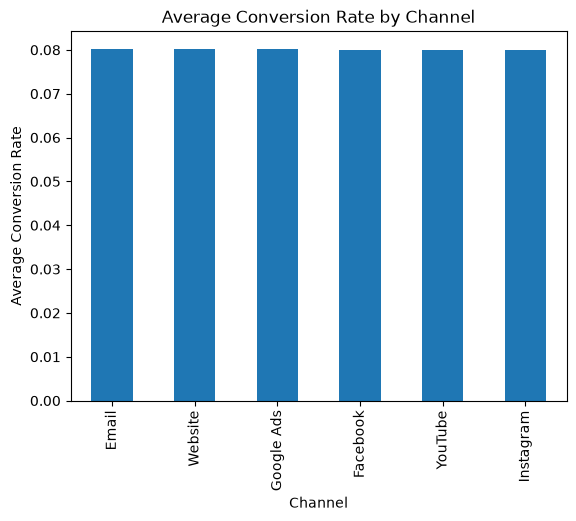

In [25]:
channel_scorecard['Avg_Conversion_Rate'].sort_values(ascending=False).plot(
    kind='bar',
    title='Average Conversion Rate by Channel',
    ylabel='Average Conversion Rate',
    xlabel='Channel'
)

<Axes: title={'center': 'Average Engagement Score by Channel'}, xlabel='Channel', ylabel='Average Engagement Score'>

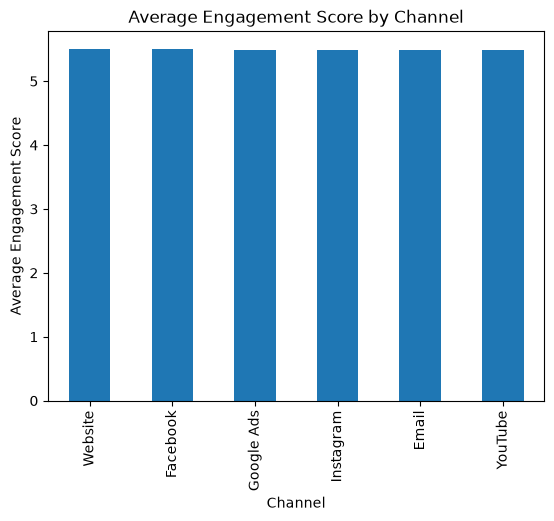

In [26]:
channel_scorecard['Avg_Engagement'].sort_values(ascending=False).plot(
    kind='bar',
    title='Average Engagement Score by Channel',
    ylabel='Average Engagement Score',
    xlabel='Channel'
)

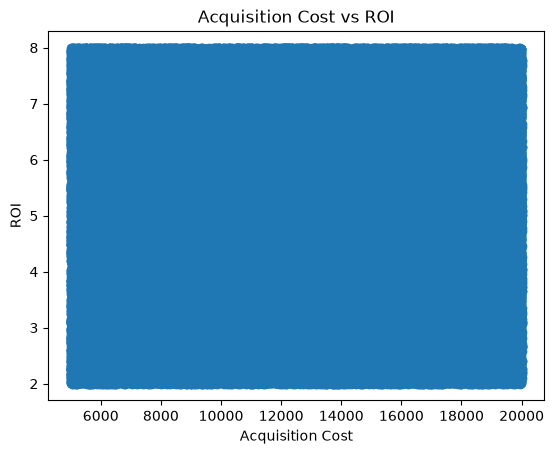

In [27]:
import matplotlib.pyplot as plt

plt.scatter(df['Acquisition_Cost'], df['ROI'])
plt.title('Acquisition Cost vs ROI')
plt.xlabel('Acquisition Cost')
plt.ylabel('ROI')
plt.show()

In [28]:
print("FINAL BUSINESS INSIGHTS")
print("-" * 40)

print("1. Facebook has the highest average ROI among the channels.")
print("2. Website has the highest average engagement score.")
print("3. Google Ads shows consistent performance across ROI and conversion rate.")
print("4. Acquisition Cost has almost no linear relationship with ROI.")
print("5. Increasing acquisition cost alone does not guarantee higher ROI.")

FINAL BUSINESS INSIGHTS
----------------------------------------
1. Facebook has the highest average ROI among the channels.
2. Website has the highest average engagement score.
3. Google Ads shows consistent performance across ROI and conversion rate.
4. Acquisition Cost has almost no linear relationship with ROI.
5. Increasing acquisition cost alone does not guarantee higher ROI.


In [29]:
print("FINAL CHANNEL SUMMARY")
print("-" * 40)

print("Highest ROI:", channel_scorecard['Avg_ROI'].idxmax())
print("Highest Conversion Rate:", channel_scorecard['Avg_Conversion_Rate'].idxmax())
print("Highest Engagement:", channel_scorecard['Avg_Engagement'].idxmax())

FINAL CHANNEL SUMMARY
----------------------------------------
Highest ROI: Facebook
Highest Conversion Rate: Email
Highest Engagement: Website


In [30]:
final_recommendation = pd.DataFrame({
    'Metric': ['ROI', 'Conversion Rate', 'Engagement'],
    'Best Channel': [
        channel_scorecard['Avg_ROI'].idxmax(),
        channel_scorecard['Avg_Conversion_Rate'].idxmax(),
        channel_scorecard['Avg_Engagement'].idxmax()
    ]
})

final_recommendation


,Metric,Best Channel
0,ROI,Facebook
1,Conversion Rate,Email
2,Engagement,Website


In [31]:
channel_scorecard['Overall_Score'] = (
    channel_scorecard['Avg_ROI'] / channel_scorecard['Avg_ROI'].max() +
    channel_scorecard['Avg_Conversion_Rate'] / channel_scorecard['Avg_Conversion_Rate'].max() +
    channel_scorecard['Avg_Engagement'] / channel_scorecard['Avg_Engagement'].max()
) / 3

channel_scorecard.sort_values('Overall_Score', ascending=False)

,Avg_ROI,Avg_Conversion_Rate,Avg_Engagement,Overall_Score
Channel_Used,,,,
Website,5.014114,0.080182,5.508828,0.999284
Facebook,5.018672,0.079990,5.503748,0.998482
Google Ads,5.003126,0.080181,5.493989,0.997650
Email,4.996487,0.080282,5.487842,0.997257
YouTube,4.993720,0.079890,5.484802,0.995262
Instagram,4.988706,0.079886,5.489039,0.995172


In [32]:
budget = {
    'Website': 20,
    'Facebook': 20,
    'Google Ads': 20,
    'Email': 15,
    'YouTube': 15,
    'Instagram': 10
}

budget_df = pd.DataFrame(
    list(budget.items()),
    columns=['Channel', 'Budget_Percentage']
)

budget_df

,Channel,Budget_Percentage
0,Website,20
1,Facebook,20
2,Google Ads,20
3,Email,15
4,YouTube,15
5,Instagram,10


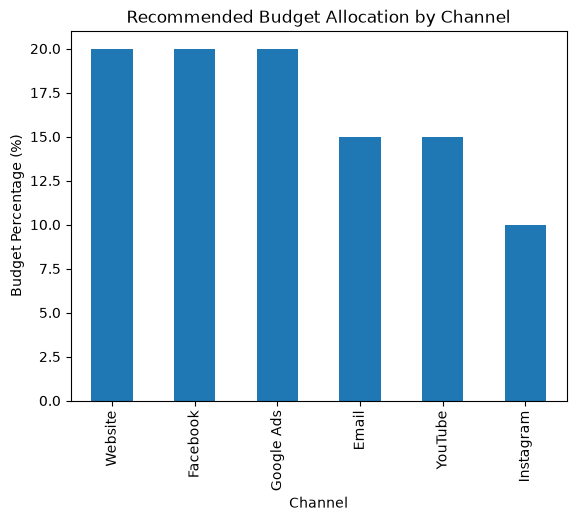

In [33]:
budget_df.plot(
    x='Channel',
    y='Budget_Percentage',
    kind='bar',
    title='Recommended Budget Allocation by Channel',
    ylabel='Budget Percentage (%)',
    xlabel='Channel',
    legend=False
)

import matplotlib.pyplot as plt
plt.show()

In [34]:
with pd.ExcelWriter('Marketing_Analysis_Final.xlsx') as writer:
    channel_scorecard.to_excel(writer, sheet_name='Channel Scorecard')
    final_recommendation.to_excel(writer, sheet_name='Best Channels', index=False)
    budget_df.to_excel(writer, sheet_name='Budget Allocation', index=False)

print("Final analysis saved successfully!")

Final analysis saved successfully!


In [35]:
print("===== FINAL PROJECT SUMMARY =====")
print("Best ROI Channel:", channel_scorecard['Avg_ROI'].idxmax())
print("Best Conversion Channel:", channel_scorecard['Avg_Conversion_Rate'].idxmax())
print("Best Engagement Channel:", channel_scorecard['Avg_Engagement'].idxmax())
print("Acquisition Cost vs ROI Correlation:", df['Acquisition_Cost'].corr(df['ROI']))
print("Total Budget Allocation:", budget_df['Budget_Percentage'].sum(), "%")

===== FINAL PROJECT SUMMARY =====
Best ROI Channel: Facebook
Best Conversion Channel: Email
Best Engagement Channel: Website
Acquisition Cost vs ROI Correlation: 0.00457463390440869
Total Budget Allocation: 100 %


In [36]:
final_summary = pd.DataFrame({
    'Analysis': [
        'Highest ROI',
        'Highest Conversion Rate',
        'Highest Engagement',
        'Acquisition Cost vs ROI Correlation',
        'Recommended Budget Allocation'
    ],
    'Result': [
        'Facebook',
        'Email',
        'Website',
        '0.0046 (Very Weak)',
        'Website 20%, Facebook 20%, Google Ads 20%, Email 15%, YouTube 15%, Instagram 10%'
    ]
})

final_summary

,Analysis,Result
0,Highest ROI,Facebook
1,Highest Conversion Rate,Email
2,Highest Engagement,Website
3,Acquisition Cost vs ROI Correlation,0.0046 (Very Weak)
4,Recommended Budget Allocation,"Website 20%, Facebook 20%, Google Ads 20%, Ema..."


In [37]:
with pd.ExcelWriter('Marketing_Analysis_Final.xlsx') as writer:
    channel_scorecard.to_excel(writer, sheet_name='Channel Scorecard')
    final_recommendation.to_excel(writer, sheet_name='Best Channels', index=False)
    budget_df.to_excel(writer, sheet_name='Budget Allocation', index=False)
    final_summary.to_excel(writer, sheet_name='Final Summary', index=False)

print("Final Excel report updated successfully!")

Final Excel report updated successfully!
